In [3]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
#### updated the code to access the file from local - THIRUVEL 
df = pd.read_csv("data/raw/customer_support_tickets.csv", encoding='utf-8')
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

### actual code
# path = kagglehub.dataset_download("suraj520/customer-support-ticket-dataset")
# print("Path to dataset files:", path)
# file_names = os.listdir(path)
# csv_file_path = os.path.join(path, 'customer_support_tickets.csv') 
# df = pd.read_csv(csv_file_path)

## Step1: Data Loading and Initial Inspection

In [5]:
print("\n 1. Shape of dataset")
print(df.shape)

print("\n 2. Basic information of the dataset")
df.info()

print("\n 3. View the first 5 rows of data")
df.head()


 1. Shape of dataset
(8469, 17)

 2. Basic information of the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   obje

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## Step2: Formatting and Missing Value Handling

In [6]:
# Convert date and time format
datetime_cols = ['Date of Purchase', 'First Response Time', 'Time to Resolution']
for col in datetime_cols:
    df[col] = pd.to_datetime(df[col])

# Handle Missing Values
df['Resolution'] = df['Resolution'].fillna('Pending/Unresolved')

## Step3: Data Visualization

C:\Users\96321\AppData\Local\Temp\ipykernel_68660\686231062.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=product_counts.values[:mid_point],
C:\Users\96321\AppData\Local\Temp\ipykernel_68660\686231062.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=product_counts.values[mid_point:],


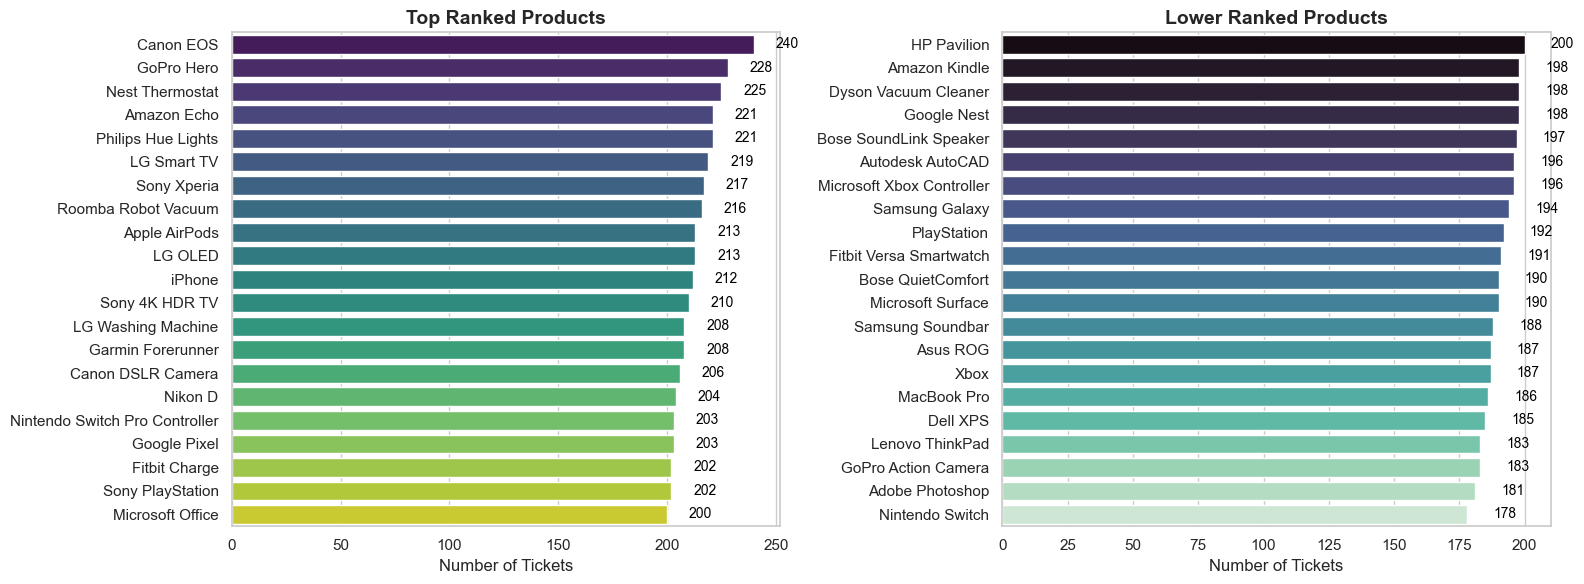

In [7]:
sns.set_theme(style="whitegrid")

product_counts = df['Product Purchased'].value_counts()

mid_point = len(product_counts) // 2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top Ranked Products
ax1 = sns.barplot(x=product_counts.values[:mid_point], 
                  y=product_counts.index[:mid_point], 
                  palette="viridis", ax=axes[0])
axes[0].set_title('Top Ranked Products', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Tickets')
axes[0].set_ylabel('') 
for i, v in enumerate(product_counts.values[:mid_point]):
    ax1.text(v + 10, i, str(v), color='black', va='center', fontsize=10)

# Lower Ranked Products
ax2 = sns.barplot(x=product_counts.values[mid_point:], 
                  y=product_counts.index[mid_point:], 
                  palette="mako", ax=axes[1])
axes[1].set_title('Lower Ranked Products', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Tickets')
axes[1].set_ylabel('') 

for i, v in enumerate(product_counts.values[mid_point:]):
    ax2.text(v + 10, i, str(v), color='black', va='center', fontsize=10)

plt.tight_layout()
plt.show()

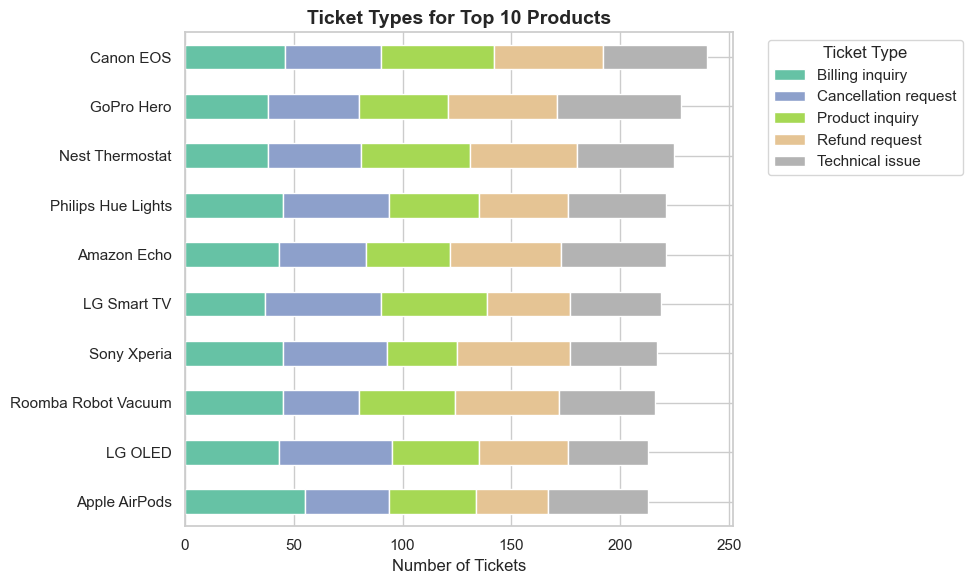

In [8]:
#Ticket Types for Top 10 Products
sns.set_theme(style="whitegrid")

top_10_names = df['Product Purchased'].value_counts().head(10).index
df_top10 = df[df['Product Purchased'].isin(top_10_names)]

cross_tab = pd.crosstab(df_top10['Product Purchased'], df_top10['Ticket Type'])

cross_tab['Total'] = cross_tab.sum(axis=1)
cross_tab = cross_tab.sort_values('Total', ascending=True).drop(columns='Total')

ax = cross_tab.plot(kind='barh', stacked=True, figsize=(10, 6), colormap='Set2')

plt.title('Ticket Types for Top 10 Products', fontsize=14, fontweight='bold')
plt.xlabel('Number of Tickets')
plt.ylabel('')
plt.legend(title='Ticket Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

C:\Users\96321\AppData\Local\Temp\ipykernel_68660\72438945.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=channel_counts.index, y=channel_counts.values, palette="Set2")


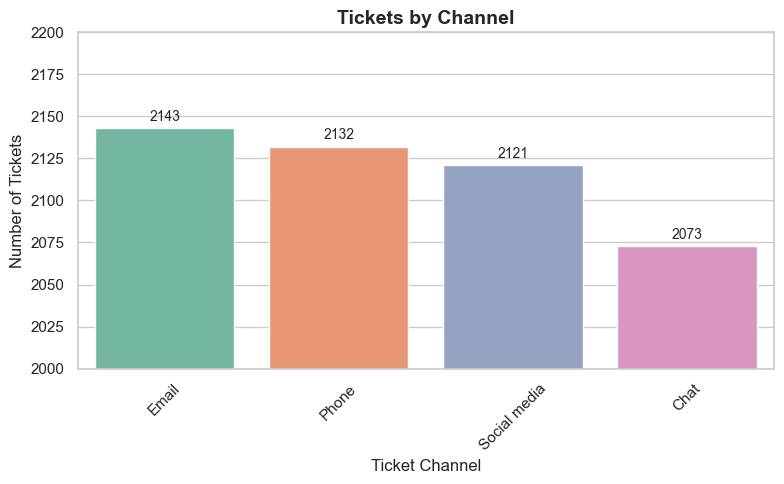

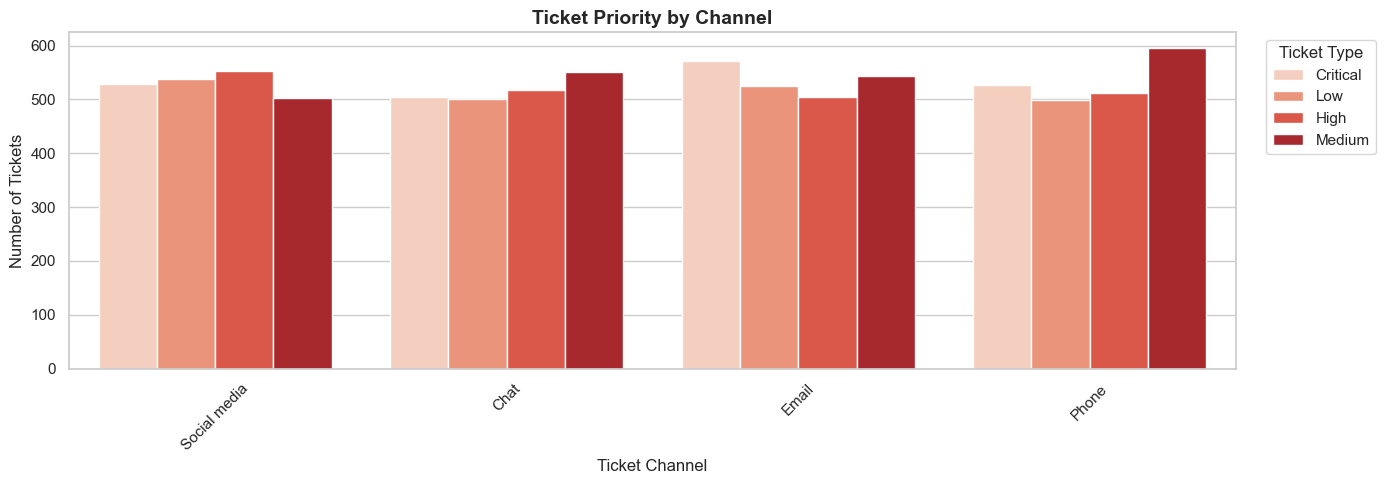

In [9]:
# Usage of customer service channels
plt.figure(figsize=(8, 5))
channel_counts = df['Ticket Channel'].value_counts()
ax = sns.barplot(x=channel_counts.index, y=channel_counts.values, palette="Set2")
plt.title('Tickets by Channel', fontsize=14, fontweight='bold')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)
plt.ylim(2000,2200)
plt.tight_layout()
plt.show()

# Channels & urgency
plt.figure(figsize=(14, 5))
sns.countplot(data=df, x='Ticket Channel', hue='Ticket Priority', palette='Reds')
plt.title('Ticket Priority by Channel', fontsize=14, fontweight='bold')
plt.xlabel('Ticket Channel')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.legend(title='Ticket Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

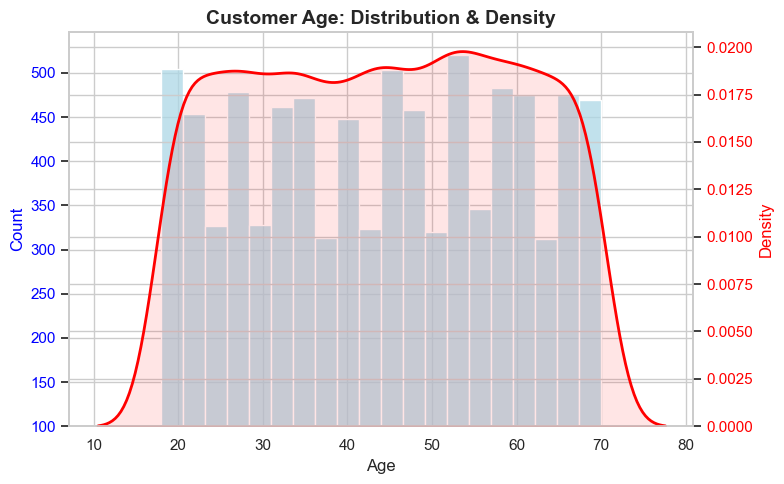

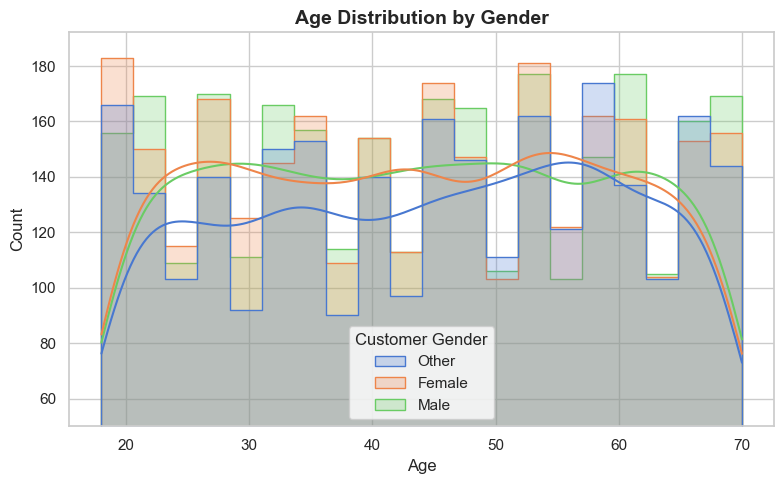

In [ ]:
# Customer Age: Distribution & Density
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

ax1 = sns.histplot(data=df, x='Customer Age', bins=20, color='lightblue')
ax1.set_xlabel('Age')
ax1.set_ylabel('Count', color='blue')
ax1.set_ylim(100)
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
sns.kdeplot(data=df, x='Customer Age', fill=True, color='red', alpha=0.1, linewidth=2, ax=ax2)
ax2.set_ylabel('Density', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Customer Age: Distribution & Density', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Age Distribution by Gender
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Customer Age', hue='Customer Gender', bins=20, kde=True, palette='muted', element="step")
plt.title('Age Distribution by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.ylim(50)
plt.tight_layout()
plt.show()

## Step4: Efficiency & Time Metrics

C:\Users\96321\AppData\Local\Temp\ipykernel_68660\1054748991.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_time.values, y=channel_time.index, palette="flare", ax=axes[0])
C:\Users\96321\AppData\Local\Temp\ipykernel_68660\1054748991.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=handling_time.values, y=handling_time.index, palette="mako", ax=axes[1])


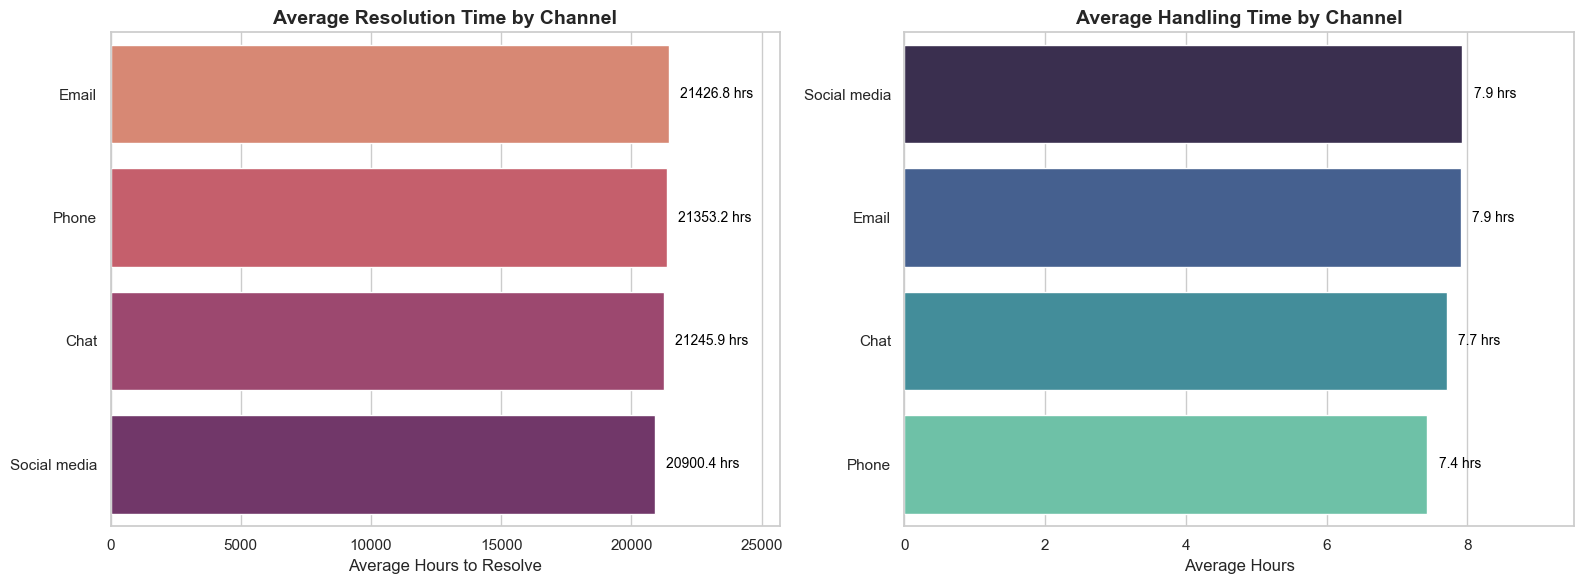

In [11]:
sns.set_theme(style="whitegrid")

df['Resolution_Time_Hours'] = (df['Time to Resolution'] - df['Date of Purchase']).dt.total_seconds() / 3600
df['Actual_Handling_Hours'] = (df['Time to Resolution'] - df['First Response Time']).dt.total_seconds() / 3600
df['Actual_Handling_Hours'] = df['Actual_Handling_Hours'].abs() 

channel_time = df.groupby('Ticket Channel')['Resolution_Time_Hours'].mean().sort_values(ascending=False)
handling_time = df.groupby('Ticket Channel')['Actual_Handling_Hours'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average Resolution Time by Channel
sns.barplot(x=channel_time.values, y=channel_time.index, palette="flare", ax=axes[0])
axes[0].set_title('Average Resolution Time by Channel', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Hours to Resolve')
axes[0].set_ylabel('')
for i, v in enumerate(channel_time.values):
    if not np.isnan(v): 
        axes[0].text(v + (channel_time.max()*0.02), i, f"{v:.1f} hrs", color='black', va='center', fontsize=10)
axes[0].set_xlim(0, channel_time.max() * 1.2)


# Average Handling Time by Channel
sns.barplot(x=handling_time.values, y=handling_time.index, palette="mako", ax=axes[1])
axes[1].set_title('Average Handling Time by Channel', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Hours')
axes[1].set_ylabel('')
for i, v in enumerate(handling_time.values):
    if not np.isnan(v):
        axes[1].text(v + (handling_time.max()*0.02), i, f"{v:.1f} hrs", color='black', va='center', fontsize=10)
axes[1].set_xlim(0, handling_time.max() * 1.2)

plt.tight_layout()
plt.show()

C:\Users\96321\AppData\Local\Temp\ipykernel_68660\2382618602.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\96321\AppData\Local\Temp\ipykernel_68660\2382618602.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


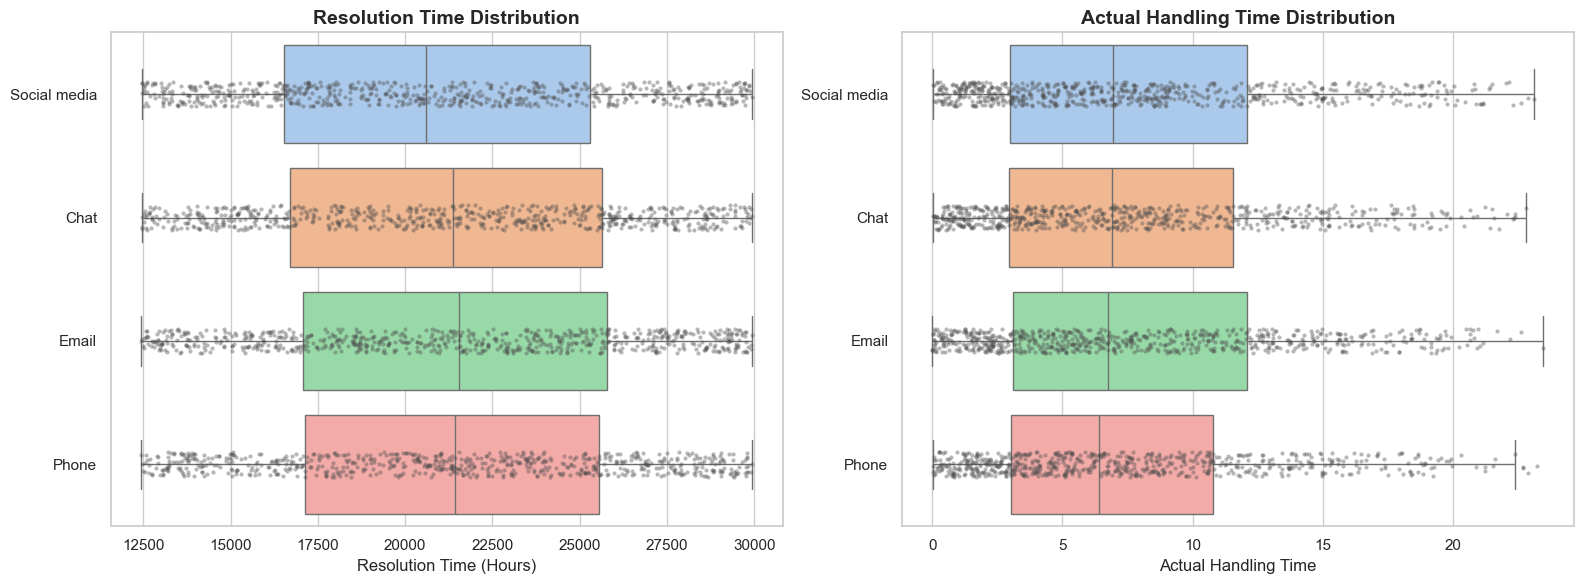

In [12]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Resolution Time Distribution
sns.boxplot(
    data=df, 
    y='Ticket Channel', 
    x='Resolution_Time_Hours', 
    palette="pastel", 
    showfliers=False,
    ax=axes[0]
)
sns.stripplot(
    data=df, 
    y='Ticket Channel', 
    x='Resolution_Time_Hours', 
    size=3, 
    color=".3", 
    alpha=0.4, 
    jitter=True,
    ax=axes[0]
)
axes[0].set_title('Resolution Time Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Resolution Time (Hours)')
axes[0].set_ylabel('')

# Actual Handling Time Distribution

sns.boxplot(
    data=df, 
    y='Ticket Channel', 
    x='Actual_Handling_Hours', 
    palette="pastel", 
    showfliers=False,
    ax=axes[1]
)
sns.stripplot(
    data=df, 
    y='Ticket Channel', 
    x='Actual_Handling_Hours', 
    size=3, 
    color=".3", 
    alpha=0.4, 
    jitter=True,
    ax=axes[1]
)
axes[1].set_title('Actual Handling Time Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Actual Handling Time')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

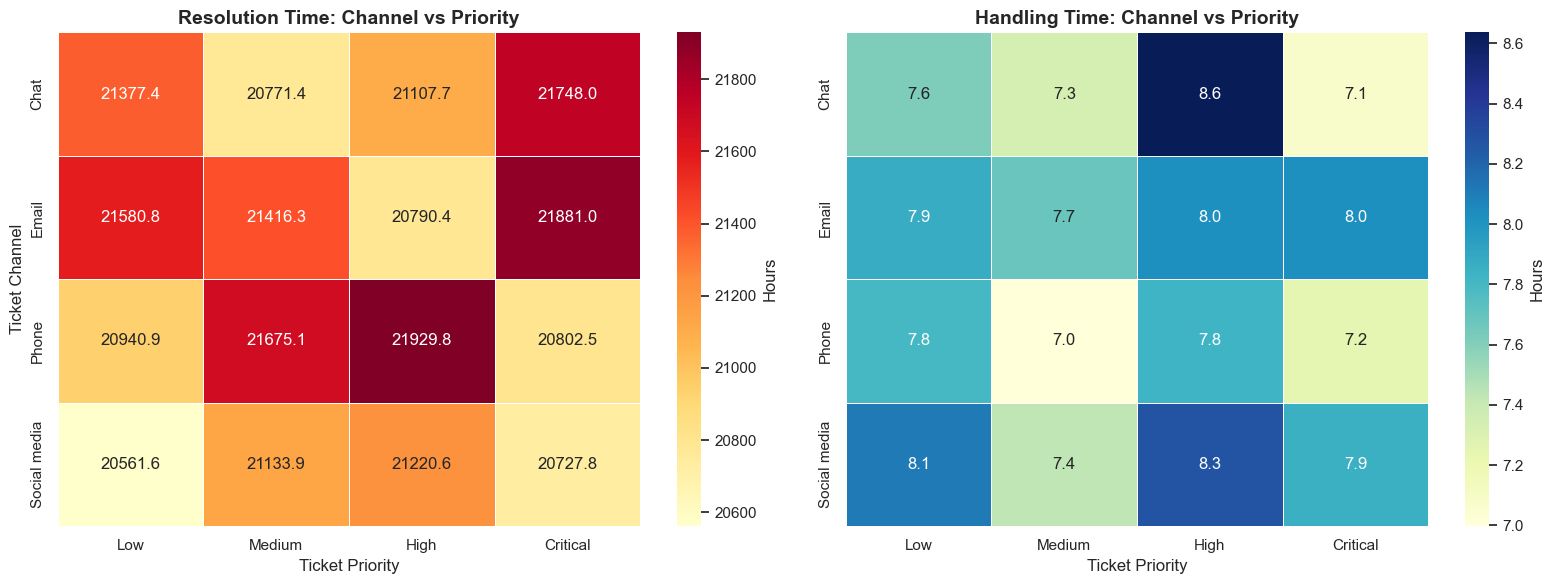

In [13]:
sns.set_theme(style="whitegrid")

priority_order = ['Low', 'Medium', 'High', 'Critical']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Resolution Time
pivot_res = df.pivot_table(
    index='Ticket Channel', 
    columns='Ticket Priority', 
    values='Resolution_Time_Hours', 
    aggfunc='mean'
)[priority_order]

sns.heatmap(
    pivot_res, 
    annot=True, fmt=".1f", cmap="YlOrRd", linewidths=.5, 
    cbar_kws={'label': 'Hours'}, ax=axes[0]
)
axes[0].set_title('Resolution Time: Channel vs Priority', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ticket Priority')
axes[0].set_ylabel('Ticket Channel')

# Actual Handling Time
pivot_hand = df.pivot_table(
    index='Ticket Channel', 
    columns='Ticket Priority', 
    values='Actual_Handling_Hours', 
    aggfunc='mean'
)[priority_order]

sns.heatmap(
    pivot_hand, 
    annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, 
    cbar_kws={'label': 'Hours'}, ax=axes[1]
)
axes[1].set_title('Handling Time: Channel vs Priority', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ticket Priority')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Step 5: Text Analysis

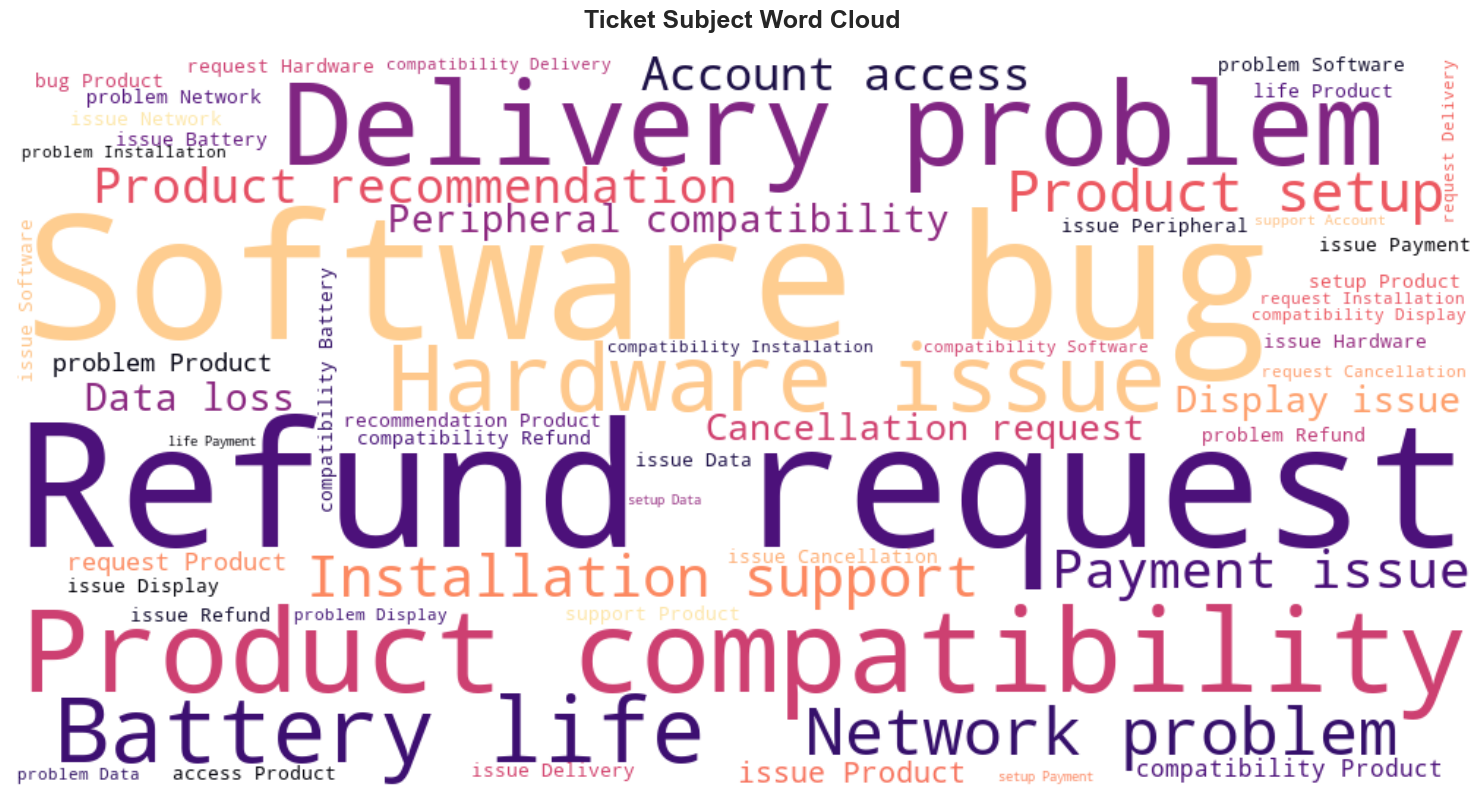

In [ ]:
# Ticket Subject Word Cloud map
text = " ".join(subject for subject in df['Ticket Subject'].dropna())

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=STOPWORDS,
    colormap='magma',
    max_words=100,
    contour_width=3,
    contour_color='steelblue'
).generate(text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Ticket Subject Word Cloud', fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

C:\Users\96321\AppData\Local\Temp\ipykernel_68660\3603139041.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Frequency', y='Phrase', data=df_top_phrases, palette="rocket")


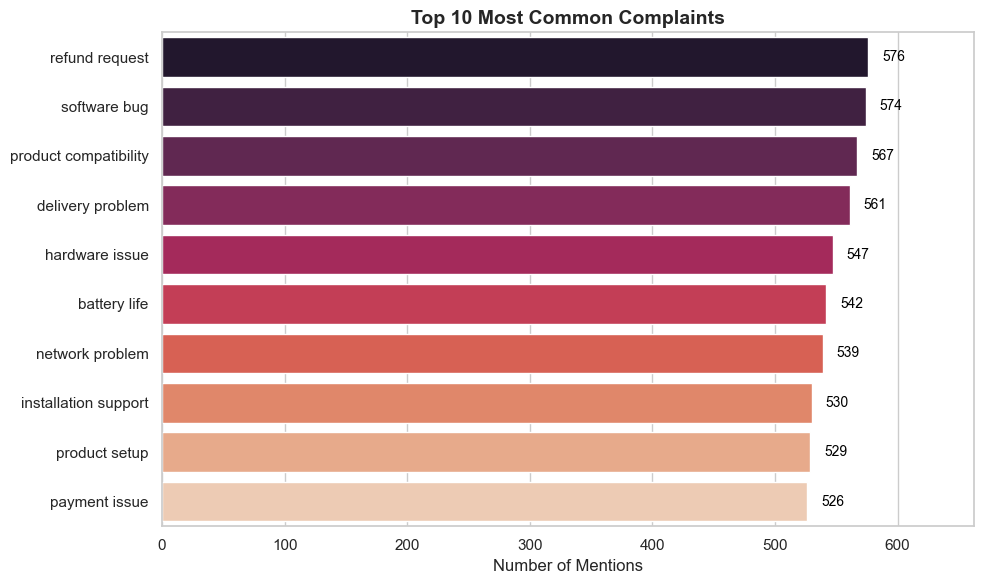

In [ ]:
# Top 10 Most Common Complaints
sns.set_theme(style="whitegrid")

vectorizer = CountVectorizer(stop_words='english', ngram_range=(2, 2))
X = vectorizer.fit_transform(df['Ticket Subject'].dropna())

sum_words = X.sum(axis=0) 
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

df_top_phrases = pd.DataFrame(words_freq[:10], columns=['Phrase', 'Frequency'])

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Frequency', y='Phrase', data=df_top_phrases, palette="rocket")
plt.title('Top 10 Most Common Complaints', fontsize=14, fontweight='bold')
plt.xlabel('Number of Mentions')
plt.ylabel('')

for i, v in enumerate(df_top_phrases['Frequency']):
    ax.text(v + (df_top_phrases['Frequency'].max() * 0.02), i, str(v), color='black', va='center', fontsize=10)

plt.xlim(0, df_top_phrases['Frequency'].max() * 1.15)
plt.tight_layout()
plt.show()

C:\Users\96321\AppData\Local\Temp\ipykernel_68660\1072100852.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_data = pd.DataFrame(index=top_phrases, columns=channels).fillna(0)


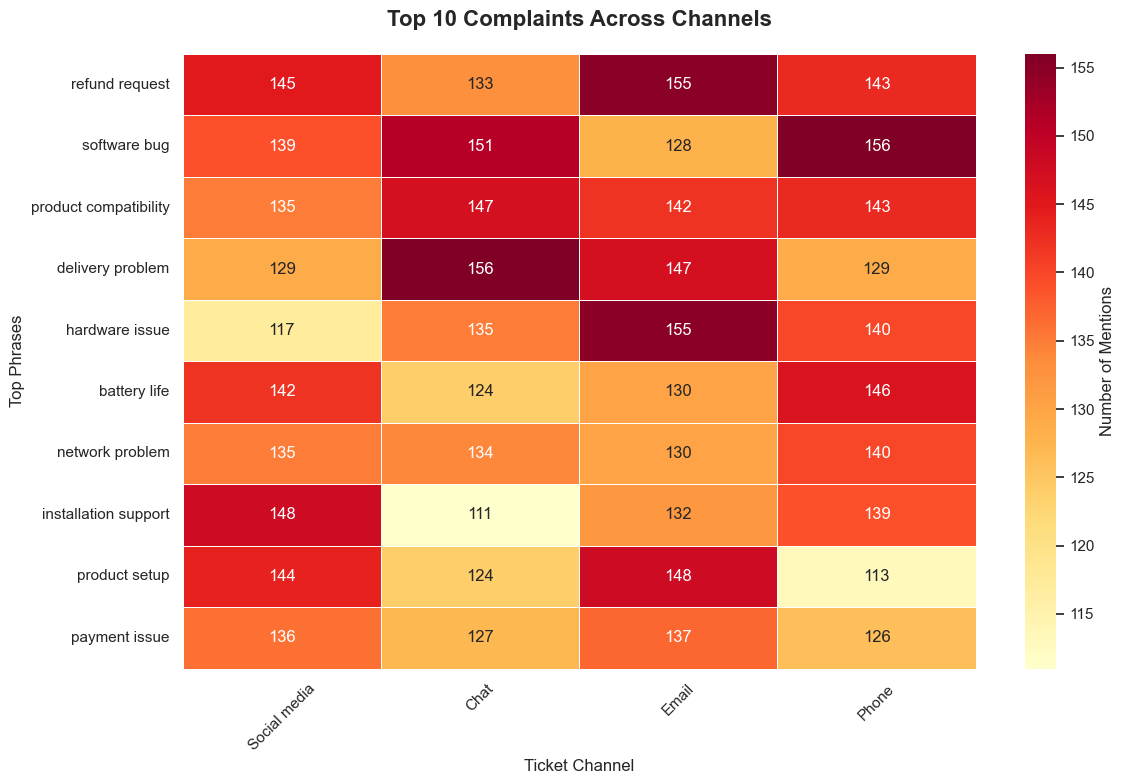

In [ ]:
# Top 10 Complaints Across Channels
sns.set_theme(style="whitegrid")

top_phrases = df_top_phrases['Phrase'].tolist()
channels = df['Ticket Channel'].dropna().unique()
heatmap_data = pd.DataFrame(index=top_phrases, columns=channels).fillna(0)
df['Subject_lower'] = df['Ticket Subject'].fillna('').str.lower()

for phrase in top_phrases:
    for channel in channels:
        count = df[(df['Ticket Channel'] == channel) & (df['Subject_lower'].str.contains(phrase, regex=False))].shape[0]
        heatmap_data.loc[phrase, channel] = count

plt.figure(figsize=(12, 8))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=.5,
    cbar_kws={'label': 'Number of Mentions'}
)

plt.title('Top 10 Complaints Across Channels', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ticket Channel', fontsize=12)
plt.ylabel('Top Phrases', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()